# NHS A&E Performance: National Trend and Trust Benchmarking

**Business question:** what drives A&E 4-hour target breaches, and which trusts are outliers, best and worst?

Data: NHS England's public provider-level A&E statistics, April 2025 to March 2026 (12 months), about 205 trusts and independent sector providers, 26.97 million attendances. See [`sql/00_setup.md`](../sql/00_setup.md) for the source files and an important note on comparing Type 1 major A&E departments fairly.

## Setup

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from portfolio import PALETTE, apply_house_style
from portfolio.paths import project_dir

apply_house_style()
pd.set_option("display.max_columns", None)

PROJECT = project_dir("02-nhs-ae")
SQL = PROJECT / "sql"
FIG = PROJECT / "outputs/figures"

con = duckdb.connect(str(PROJECT / "data/processed/nhs_ae.duckdb"))

def run(sql_file):
    return con.execute((SQL / sql_file).read_text()).fetchdf()

## 1. Data overview

In [2]:
run("01_data_overview.sql")

,months,distinct_providers,provider_month_rows,total_attendances
0,12,205,2386,26969593.0


205 distinct providers across 12 months, 26.97 million attendances. Note the embedded national "TOTAL" summary row each monthly file includes is excluded throughout, so every figure here is built up from the individual provider rows, not taken from NHS England's own pre-computed total.

## 2. The national trend

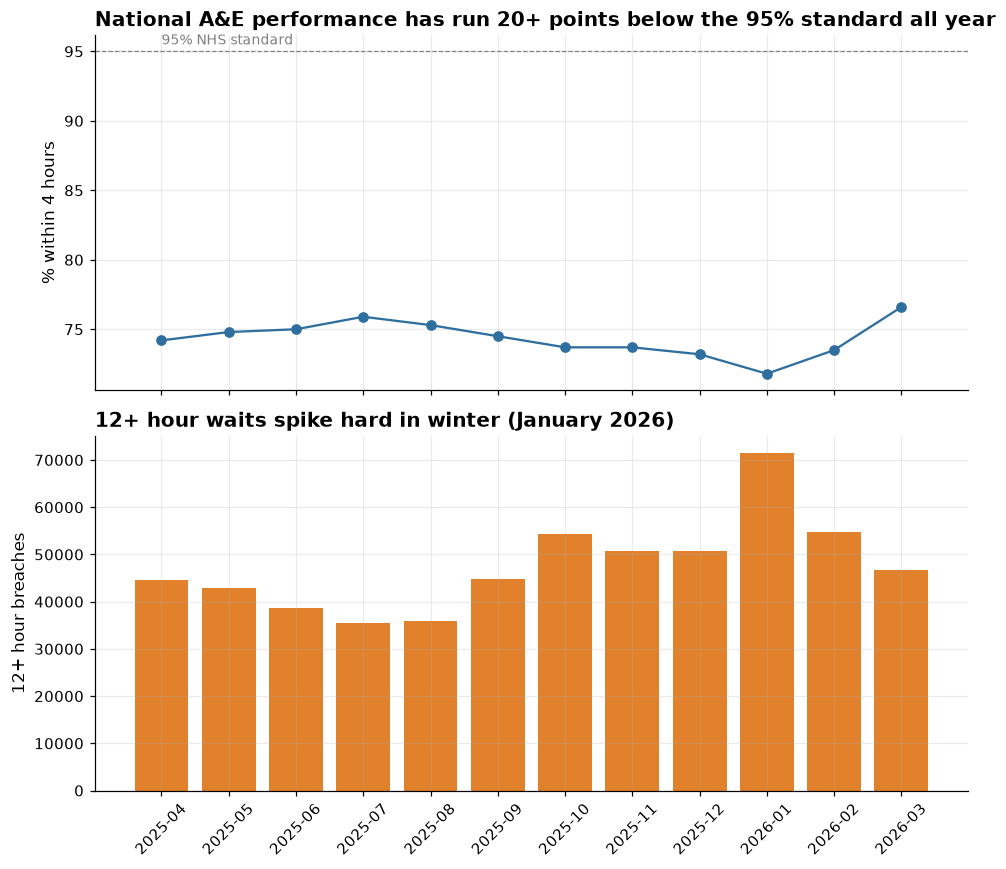

In [3]:
trend = run("02_national_trend.sql")
fig, axes = plt.subplots(2, 1, figsize=(9, 8), sharex=True)
axes[0].plot(trend["month"], trend["pct_within_4hrs"], marker="o", color=PALETTE[0])
axes[0].axhline(95, color="grey", linestyle="--", linewidth=0.8)
axes[0].text(0, 95.5, "95% NHS standard", fontsize=9, color="grey")
axes[0].set_ylabel("% within 4 hours")
axes[0].set_title("National A&E performance has run 20+ points below the 95% standard all year")
axes[1].bar(trend["month"], trend["total_12hr_plus_breaches"], color=PALETTE[1])
axes[1].set_ylabel("12+ hour breaches")
axes[1].set_title("12+ hour waits spike hard in winter (January 2026)")
for ax in axes:
    ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIG / "01_national_trend.png")
plt.show()

**Finding:** national 4-hour performance has sat between 71.8% and 76.6% across the whole year, well below the NHS's own 95% standard every single month. Performance and 12-hour breaches both move together with the season: October through January is clearly the worst stretch, bottoming out in January 2026 at 71.8% performance and 71,517 breaches over 12 hours, more than double July's figure. This is winter pressure showing up exactly where NHS commentary always says it will, but now with the actual scale attached.

## 3. Which trusts are the clearest outliers on Type 1 performance?

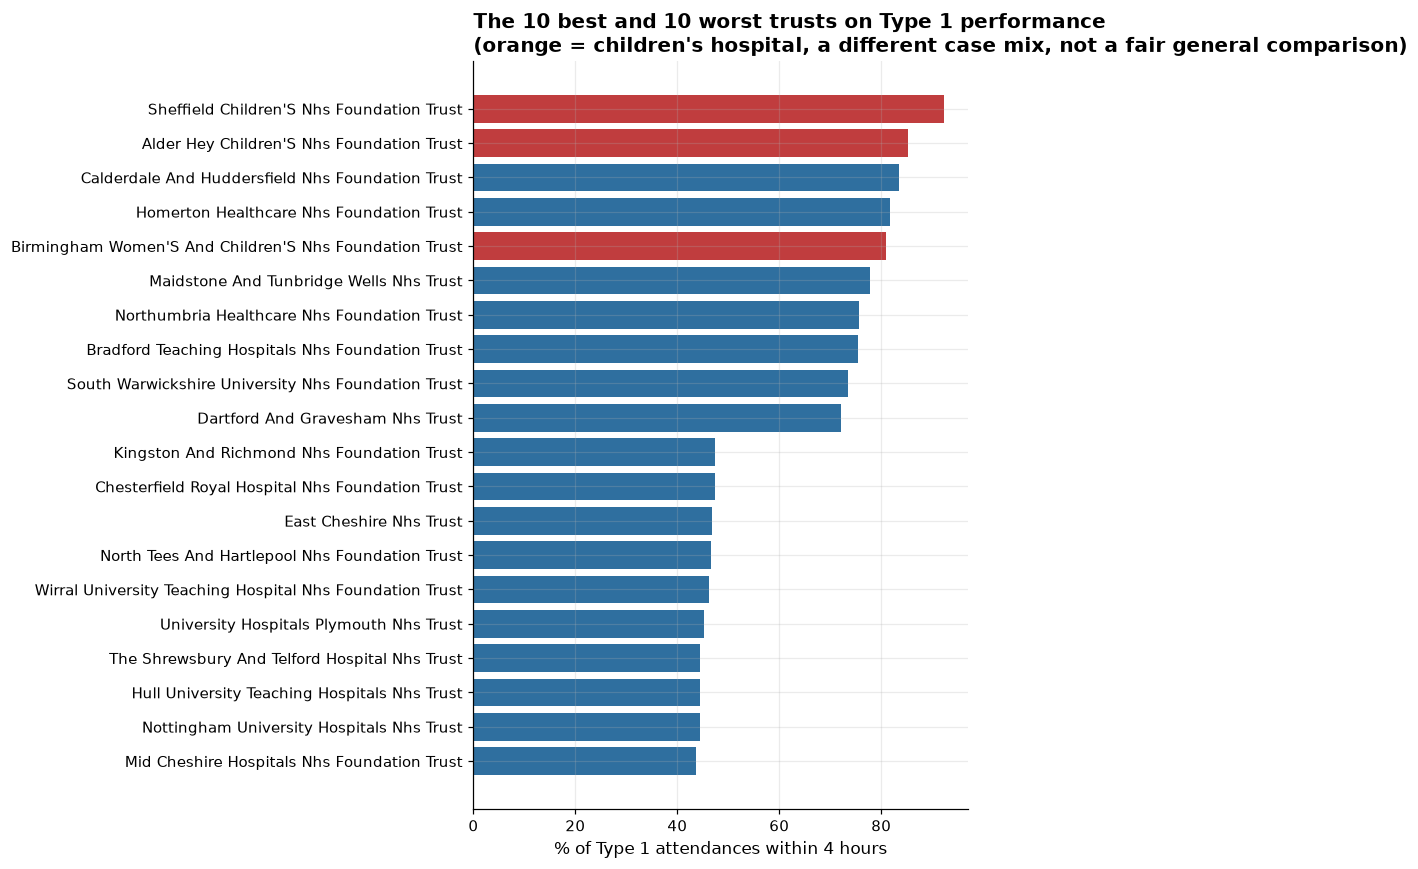

In [4]:
perf = run("03_trust_type1_performance.sql")
top10 = perf.head(10)
bottom10 = perf.tail(10)
combo = pd.concat([bottom10, top10]).sort_values("pct_within_4hrs")
colors = [PALETTE[3] if "CHILDREN" in t else PALETTE[0] for t in combo["trust"]]
fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(combo["trust"].str.title(), combo["pct_within_4hrs"], color=colors)
ax.set_xlabel("% of Type 1 attendances within 4 hours")
ax.set_title("The 10 best and 10 worst trusts on Type 1 performance\n(orange = children's hospital, a different case mix, not a fair general comparison)")
fig.tight_layout()
fig.savefig(FIG / "02_trust_outliers.png")
plt.show()

**Finding:** the two best-performing trusts, Sheffield Children's (92.4%) and Alder Hey Children's (85.2%), are both specialist children's hospitals, not general hospitals doing something replicable. Children's A&E departments see a different, generally less complex case mix than adult general hospitals, so this is a genuine confound, not a best-practice story to copy directly. Excluding those two, the real top performer among general trusts is Calderdale and Huddersfield at 83.4%. The worst performers cluster in the low 50s to high 50s percent, a full 20 to 25 points below the best general trusts, on the same national standard.

## 4. Does the severe end of the problem vary by region?

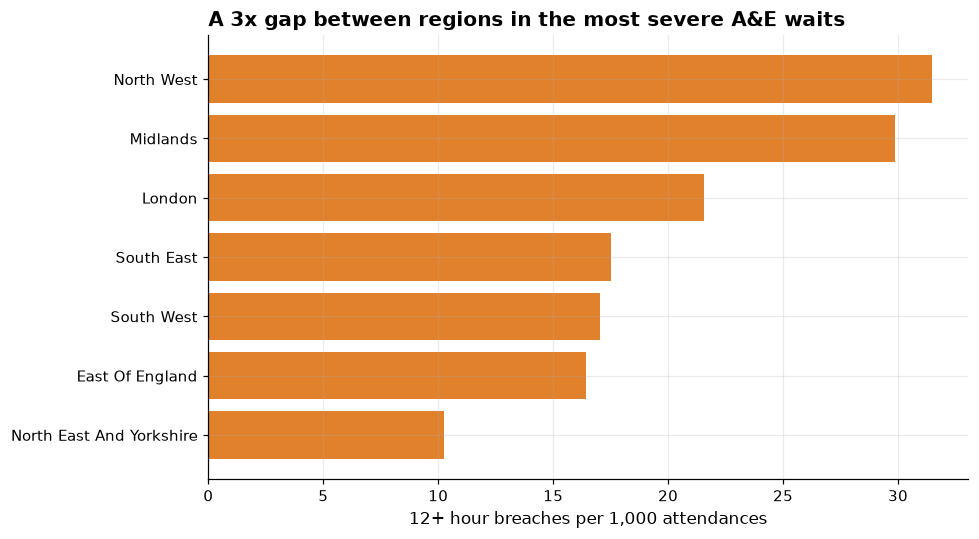

In [5]:
reg = run("04_regional_12hr_breaches.sql").sort_values("breaches_per_1000_attendances")
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(reg["region"].str.replace("NHS ENGLAND ", "").str.title(), reg["breaches_per_1000_attendances"], color=PALETTE[1])
ax.set_xlabel("12+ hour breaches per 1,000 attendances")
ax.set_title("A 3x gap between regions in the most severe A&E waits")
fig.tight_layout()
fig.savefig(FIG / "03_regional_breaches.png")
plt.show()

**Finding:** North East and Yorkshire has the fewest severe breaches relative to volume (10.27 per 1,000 attendances), while North West has the most (31.47 per 1,000), roughly three times worse on the same measure. This is a genuinely large regional gap, and it's the most severe end of the problem specifically, patients waiting 12 or more hours, not the more forgiving 4-hour measure, which is the one most likely to reflect real patient harm.

## 5. Does trust size explain performance?

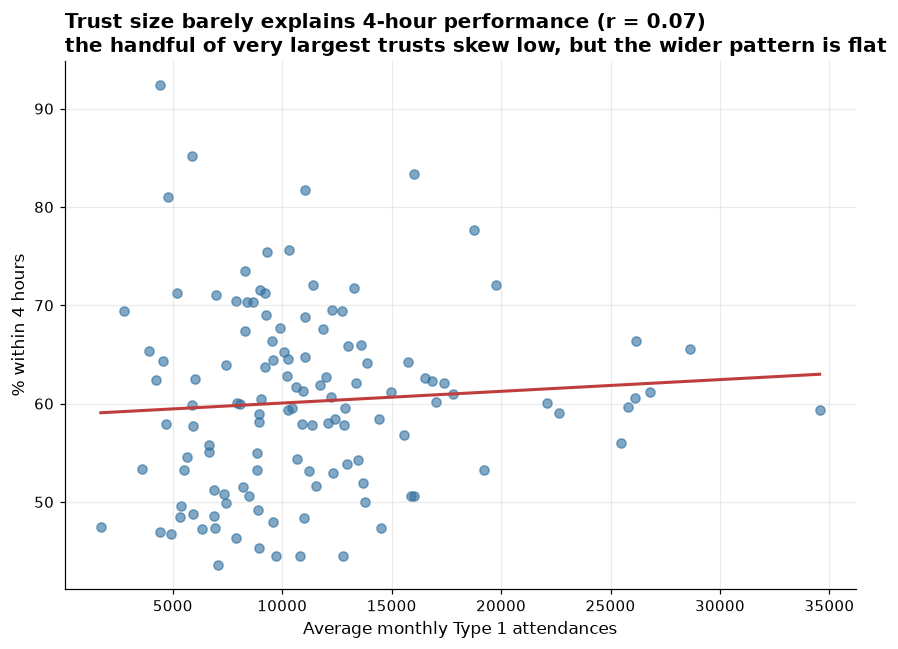

correlation: 0.072


In [6]:
vol = run("05_volume_vs_performance.sql")
corr = vol["avg_monthly_type1_attendances"].corr(vol["pct_within_4hrs"])
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(vol["avg_monthly_type1_attendances"], vol["pct_within_4hrs"], color=PALETTE[0], alpha=0.6)
z = np.polyfit(vol["avg_monthly_type1_attendances"], vol["pct_within_4hrs"], 1)
xs = np.linspace(vol["avg_monthly_type1_attendances"].min(), vol["avg_monthly_type1_attendances"].max(), 50)
ax.plot(xs, np.polyval(z, xs), color=PALETTE[3], linewidth=2)
ax.set_xlabel("Average monthly Type 1 attendances")
ax.set_ylabel("% within 4 hours")
ax.set_title(f"Trust size barely explains 4-hour performance (r = {corr:.2f})\nthe handful of very largest trusts skew low, but the wider pattern is flat")
fig.tight_layout()
fig.savefig(FIG / "04_volume_vs_performance.png")
plt.show()
print(f"correlation: {corr:.3f}")

**Finding:** the correlation between a trust's average monthly Type 1 volume and its 4-hour performance is 0.07, essentially no linear relationship across the 124 trusts with a meaningful Type 1 department. Eyeballing just the handful of very largest trusts (Birmingham, Manchester, Barts Health) does suggest they skew toward below-average performance, but that pattern does not hold once the full range of trust sizes is considered: several mid-sized and even some large trusts perform well above average. This matters because it argues against "trusts are struggling because they're big" as a general explanation, and toward something more specific to each trust, staffing, local demand mix, bed availability, or discharge flow, being the more useful place to look.

## Summary

See [`report.md`](../report.md) for the full written analysis, and [`README.md`](../README.md) for the one-page version.